In [274]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.io import loadmat
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.transform import iradon
from tqdm import tqdm
from joblib import Parallel, delayed
import time
import cv2
import math
import pickle
from collections import defaultdict
import re

constants

In [275]:
figures_path = "/Users/piotrblaszyk/Documents/university/MRIGI/med-surg-imaging-70003/cw/figures/"
code_path = "/Users/piotrblaszyk/Documents/university/MRIGI/med-surg-imaging-70003/cw/code/"
show_all_slices = False
compute_all_slices = False
compute_axial_reconstruction = False
compute_helical_sinograms = False

utility functions

In [289]:
def normalise_string(input_string):
    lowercased_string = input_string.lower()
    normalized_string = re.sub(r'\s+', '-', lowercased_string)
    return normalized_string

def show_gray_img(img):
    plt.figure()
    plt.imshow(img, cmap='gray', origin='lower')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

def show_images(imgs, titles, rectangles):
    n = len(imgs)
    num_rows = math.ceil(n / 3)
    num_cols = 3
    img_side = 4
    fig,axes=plt.subplots(num_rows, num_cols, figsize=(img_side * num_cols, img_side * num_rows))
    axes=axes.ravel()
    for i,ax in enumerate(axes):
        if i<len(imgs):
            ax.imshow(imgs[i],cmap='gray',origin='lower')
            ax.axis('on')
            if titles is not None:
                ax.set_title(titles[i])

            for j in range(len(rectangles)):
                bot_left_x, bot_left_y, width, height = rectangles[j]
                rect = patches.Rectangle((bot_left_x, bot_left_y), width, height, linewidth=1, edgecolor='r', linestyle='--', fill=False)
                ax.add_patch(rect)

        else:fig.delaxes(ax)
    plt.tight_layout()
    plt.show()

def save_images(imgs, titles):
    for i in range(len(imgs)):
        plt.imsave(f'{figures_path}{normalise_string(titles[i])}.png', imgs[i], cmap='gray', origin='lower')

def rotate(img, angle, crop=True):
    (h,w)=img.shape[:2]
    angle_rad=np.deg2rad(angle)
    center=(w//2,h//2)
    rotation_matrix=cv2.getRotationMatrix2D(center,angle,1.0)
    if not crop:
        new_w=int(abs(w*np.cos(angle_rad))+abs(h*np.sin(angle_rad)))
        new_h=int(abs(w*np.sin(angle_rad))+abs(h*np.cos(angle_rad)))
        rotation_matrix[0,2]+=(new_w-w)/2
        rotation_matrix[1,2]+=(new_h-h)/2
    else:
        new_w = w
        new_h = h
    return cv2.warpAffine(img,rotation_matrix,(new_w, new_h))

def interpolate(arr, i):
    if i < 0 or i > len(arr) - 1:
        raise Exception(f"Index {i} out of bounds for array size {len(arr)}")
    a = math.floor(i)
    b = math.ceil(i)
    if a == b and int(a) == a:
        return arr[int(a)]
    assert b == a + 1, f"{b} != {a} + 1"
    return abs(i - a) * arr[a] + abs(b - i) * arr[b]

def calc_snr(roi):
    signal = np.mean(roi)
    noise = np.std(roi)
    if noise == 0:
        raise Exception("noise is 0, cannot calculate SNR")
    return signal / noise

def aggregate_snr_rms(rois):
    snr_values = []
    for roi in rois:
        snr = calc_snr(roi)
        snr_values.append(snr * snr)
    if not snr_values:
        raise Exception("No valid SNR values calculated")
    return np.sqrt(np.mean(snr_values))

def calc_cnr_single(target_roi, background_roi):
    mean_target = np.mean(target_roi)
    mean_background = np.mean(background_roi)
    noise = np.std(background_roi)
    contrast = abs(mean_target - mean_background)
    if noise == 0:
        raise Exception("noise is 0, cannot compute CNR")
    return contrast / noise

def calc_cnr_aggregate(target_rois, background_rois):
    contrasts = []
    noises = []
    for i in range(len(target_rois)):
        mean_target = np.mean(target_rois[i])
        mean_background = np.mean(background_rois[i])
        noise = np.std(background_rois[i])
        contrasts.append(abs(mean_target - mean_background))
        noises.append(noise)
    mean_contrast = np.mean(contrasts)
    mean_noise = np.mean(noises)
    if mean_noise == 0:
        raise Exception("noise is 0, cannot compute CNR")
    return mean_contrast / mean_noise

load CT projection dataset

In [277]:
ct_projections_path = '/Users/piotrblaszyk/Documents/university/MRIGI/med-surg-imaging-70003/tutorials/msi-2-tutorial-m/CT projections.mat'
mat_data = loadmat(ct_projections_path)
axial_sinograms = mat_data['projections']
print("Axial dataset shape:", axial_sinograms.shape)
n_slices, n_detectors, n_angles = axial_sinograms.shape

Axial dataset shape: (190, 380, 180)


reconstruct

In [278]:
axial_reconstructions_filename = f"{code_path}axial_reconstructions.pkl"
if compute_axial_reconstruction:
    axial_reconstructions = np.zeros((n_slices, n_detectors, n_detectors))
    for i in tqdm(range(n_slices)):
        theta = np.linspace(0, n_angles, n_angles, endpoint=False)
        axial_reconstructions[i] = iradon(axial_sinograms[i, :, :], theta=theta, filter_name="hann", circle=True)
    with open(axial_reconstructions_filename, 'wb') as file:
        pickle.dump(axial_reconstructions, file)
else:
     with open(axial_reconstructions_filename, 'rb') as file:
        axial_reconstructions = pickle.load(file)

print(axial_reconstructions.shape)

(190, 380, 380)


-0.0012414015991504873 0.03451338003285026


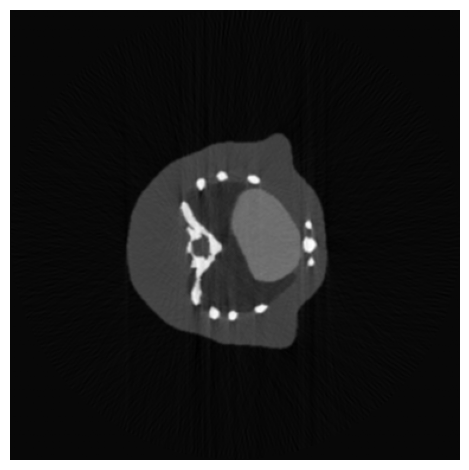

In [279]:
img = axial_reconstructions[109]
print(np.min(img), np.max(img))
show_gray_img(img)

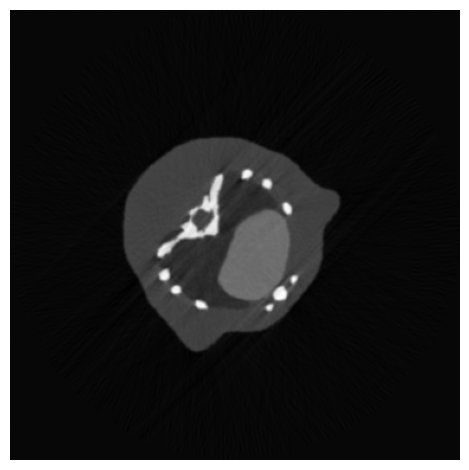

In [280]:
show_gray_img(rotate(img, angle=45))

compute helical sinograms (mine)

In [281]:
helical_sinograms_filename = f"{code_path}helical_sinograms.pkl"
num_table_movements = 19
num_detector_elements = 380
num_detector_rows = 10
num_projections_per_axial_scan = 180
pitches = [1.0, 2.0]

if compute_helical_sinograms:
    helical_sinograms = []
    for i in range(len(pitches)):
        table_movement_per_half_rotation = num_detector_rows * pitches[i]
        total_z_length = num_table_movements * num_detector_rows
        delta_z = table_movement_per_half_rotation / num_projections_per_axial_scan

        delta_theta = 1
        z = 0
        theta = 0
        with tqdm(total=total_z_length, desc="Processing") as pbar:
            while True:
                len_start = len(helical_sinograms)
                for k in range(num_detector_rows):
                    z_detector_row = z + k
                    if z_detector_row < total_z_length - 1:
                        slice_reconstructed = interpolate(axial_reconstructions, z_detector_row)
                        slice_reconstructed_rotated = rotate(slice_reconstructed, theta)
                        projection_1d = np.mean(slice_reconstructed_rotated, axis=0)
                        helical_sinograms.append((pitches[i], theta, z_detector_row, projection_1d))
                len_end = len(helical_sinograms)
                if len_start == len_end:
                    break
                z += delta_z
                theta += delta_theta
                theta %= 360
                pbar.update(math.floor(z) - pbar.n)
    helical_sinograms.sort(key=lambda item: (item[0], item[1], item[2]))
    with open(helical_sinograms_filename, 'wb') as file:
        pickle.dump(helical_sinograms, file)
else:
    with open(helical_sinograms_filename, 'rb') as file:
        helical_sinograms = pickle.load(file)

print(len(helical_sinograms))

49825


In [282]:
print([x[:1] for x in helical_sinograms[:3]])
print([x[:1] for x in helical_sinograms[-3:]])

[(1.0,), (1.0,), (1.0,)]
[(2.0,), (2.0,), (2.0,)]


calculate helical sinogram for target slice

In [283]:
# slices: 0 - 189
# target slice = 109
# span: table_movement_per_half_rotation
# span / 2 : table_movement_per_half_rotation / 2
# centre: z_detector_row = 109
# obtain all angles 0 - 179
# minimise z_detector_row
# for each angle
# scan helical_sinograms, obtain projection _1d that minimises z_detector_row
# save to a numpy arr of shape: (180, 380, 380)
helical_sinogram_target_half_slices = []
thetass = []
for j in range(len(pitches)):
    print(f'pitch = {pitches[j]}')
    print()
    helical_sinogram_target_slice_half = []
    thetas = []
    foo = defaultdict(lambda: (float('inf'), -1, -1))
    target_slice = 109
    for i in range(len(helical_sinograms)):
        pitch, theta, z_detector_row, projection_1d = helical_sinograms[i]
        if pitch == pitches[j]:
            foo_dist, _, _ = foo[theta]
            cur_dist = abs(target_slice - z_detector_row)
            if cur_dist < foo_dist:
                foo[theta] = (cur_dist, i, z_detector_row)

    assert set(foo.keys()) == set(range(num_projections_per_axial_scan * 2)), f"Dict keys don't correspond to {min(range(num_projections_per_axial_scan * 2))} - {max(range(num_projections_per_axial_scan * 2))}"
    distances = []
    print('all')
    for i in range(num_projections_per_axial_scan * 2):
        foo_dist, j, j_z = foo[i]
        distances.append(foo_dist)
        print(i, f"{j_z:.2f}", f"{foo_dist:.2f}")
    print()
    distances += distances
    min_dist_sum = float('inf')
    min_dist_start_ix = -1
    for i in range(num_projections_per_axial_scan * 2):
        cur_dist_sum = sum(distances[i : i + num_projections_per_axial_scan])
        if cur_dist_sum < min_dist_sum:
            min_dist_sum = cur_dist_sum
            min_dist_start_ix = i
    assert min_dist_start_ix != -1, "min_dist_start_ix wasn't calculated properly"
    print('chosen')
    for k in range(num_projections_per_axial_scan):
        i = min_dist_start_ix + k
        i %= (num_projections_per_axial_scan * 2)
        foo_dist, j, j_z = foo[i]
        pitch, theta, z_detector_row, projection_1d = helical_sinograms[j]
        helical_sinogram_target_slice_half.append(projection_1d)
        thetas.append(theta)
        print(theta, f"{z_detector_row:.2f}", f"{foo_dist:.2f}")

    helical_sinogram_target_slice_half = np.array(helical_sinogram_target_slice_half)
    thetas = np.array(thetas)
    helical_sinogram_target_slice_half = helical_sinogram_target_slice_half.T
    assert helical_sinogram_target_slice_half.shape == (num_detector_elements, num_projections_per_axial_scan), f"helical_sinogram_target_slice_half's shape isn't appropriate for iradon to accept"
    helical_sinogram_target_half_slices.append(helical_sinogram_target_slice_half)
    thetass.append(thetas)
    print()

pitch = 1.0

all
0 109.00 0.00
1 109.06 0.06
2 109.11 0.11
3 109.17 0.17
4 109.22 0.22
5 109.28 0.28
6 109.33 0.33
7 109.39 0.39
8 109.44 0.44
9 108.50 0.50
10 108.56 0.44
11 108.61 0.39
12 108.67 0.33
13 108.72 0.28
14 108.78 0.22
15 108.83 0.17
16 108.89 0.11
17 108.94 0.06
18 109.00 0.00
19 109.06 0.06
20 109.11 0.11
21 109.17 0.17
22 109.22 0.22
23 109.28 0.28
24 109.33 0.33
25 109.39 0.39
26 109.44 0.44
27 108.50 0.50
28 108.56 0.44
29 108.61 0.39
30 108.67 0.33
31 108.72 0.28
32 108.78 0.22
33 108.83 0.17
34 108.89 0.11
35 108.94 0.06
36 109.00 0.00
37 109.06 0.06
38 109.11 0.11
39 109.17 0.17
40 109.22 0.22
41 109.28 0.28
42 109.33 0.33
43 109.39 0.39
44 109.44 0.44
45 108.50 0.50
46 108.56 0.44
47 108.61 0.39
48 108.67 0.33
49 108.72 0.28
50 108.78 0.22
51 108.83 0.17
52 108.89 0.11
53 108.94 0.06
54 109.00 0.00
55 109.06 0.06
56 109.11 0.11
57 109.17 0.17
58 109.22 0.22
59 109.28 0.28
60 109.33 0.33
61 109.39 0.39
62 109.44 0.44
63 108.50 0.50
64 108.56 0.44
65 108.61 0.39
66 

reconstruct helical target slice

In [284]:
helical_reconstructions_half = []
for i in range(len(pitches)):
    helical_reconstructions_half.append(iradon(helical_sinogram_target_half_slices[i], theta=thetass[i], filter_name="hann", circle=True))

show axial target slice and helical target slice

(380, 380)
(190, 190)


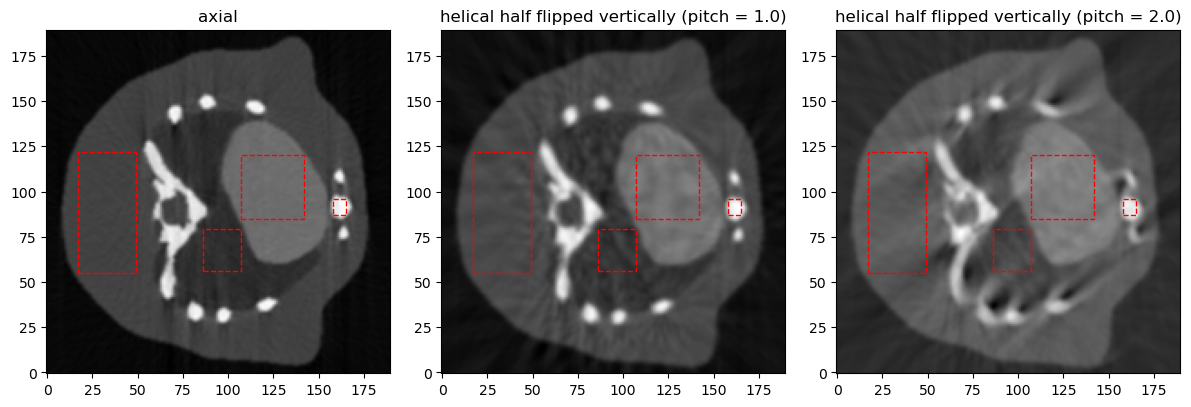

In [312]:
axial_reconstruction = axial_reconstructions[109]
helical_reconstructions_half_flipped_vertically = [x[::-1, :] for x in helical_reconstructions_half]
imgs = [
    axial_reconstruction,
]
titles = [
    'axial',
]
file_names = [
    'axial',
]
for i in range(len(pitches)):
    imgs.append(helical_reconstructions_half_flipped_vertically[i])
    titles.append(f'helical half flipped vertically (pitch = {pitches[i]})')
    file_names.append(f'helical-{round(pitches[i])}')
for i in range(len(imgs)):
    x, _ = imgs[i].shape
    start_ix = 90
    end_ix = 280
    imgs[i] = imgs[i][start_ix:end_ix, start_ix:end_ix]
    min_val = np.min(imgs[i])
    max_val = np.max(imgs[i])
    if max_val - min_val == 0:
        raise Exception("Dynamic range of image is 0 - cannot normalise")
    imgs[i] = (imgs[i] - min_val) / (max_val - min_val)
# origin is in top-left corner of the image
# (target, background)
# [top_left_x, top_left_y, bottom_right_x, bottom_right_y]
rectangles = [
    [17, 55, 32, 67],
    [86, 56, 21, 23],
    [107, 85, 35, 35],
    [158, 87, 7, 9],
]
print(axial_reconstruction.shape)
print(imgs[0].shape)
show_images(imgs, titles, rectangles)
save_images(imgs, file_names)

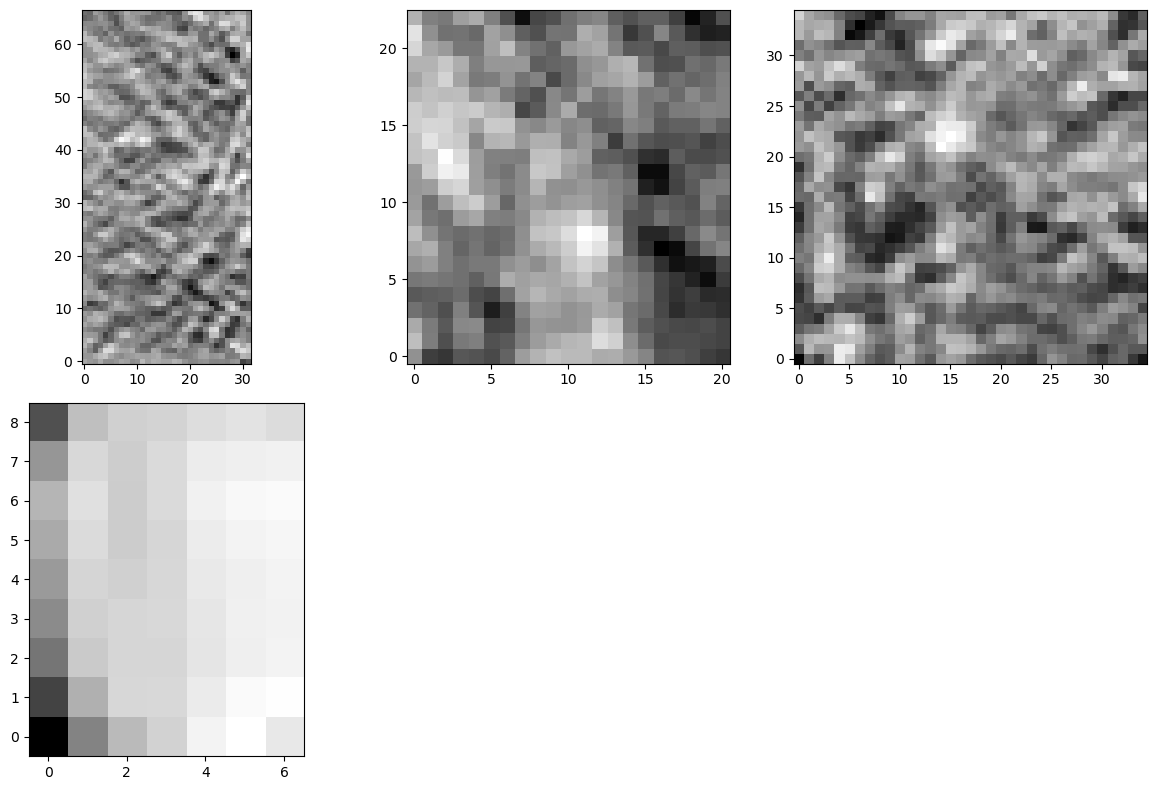

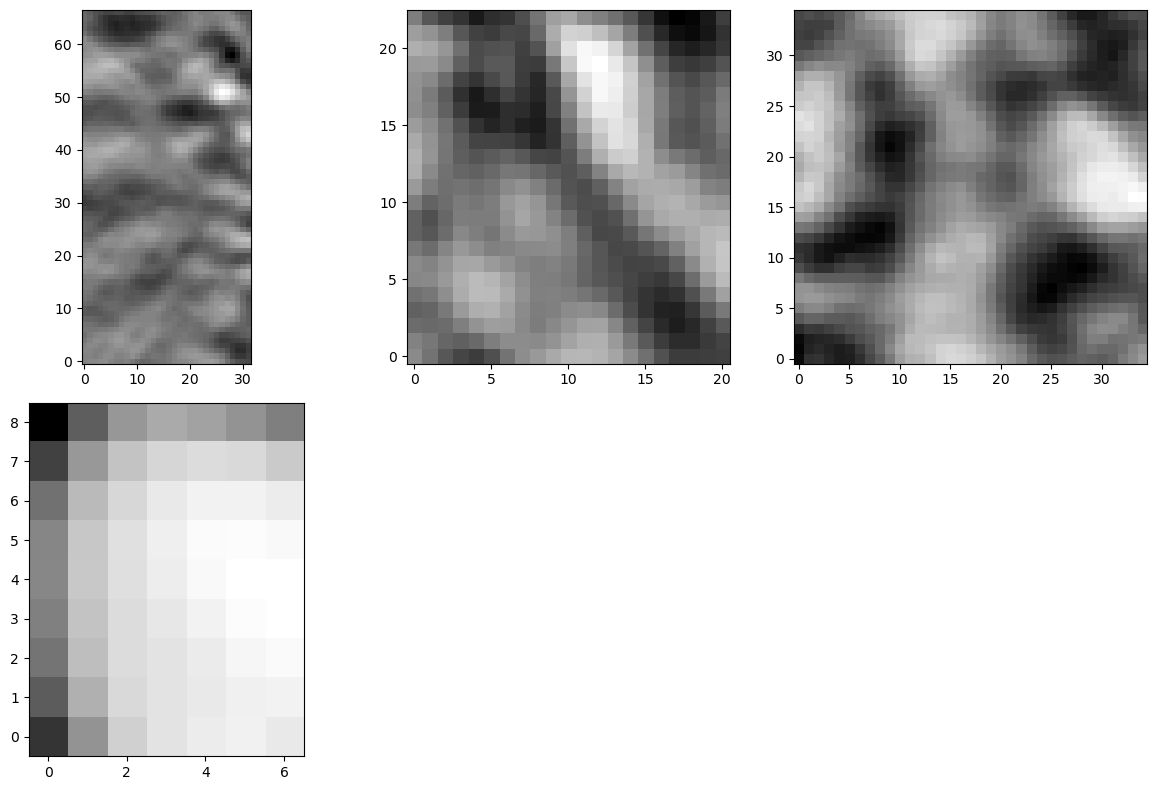

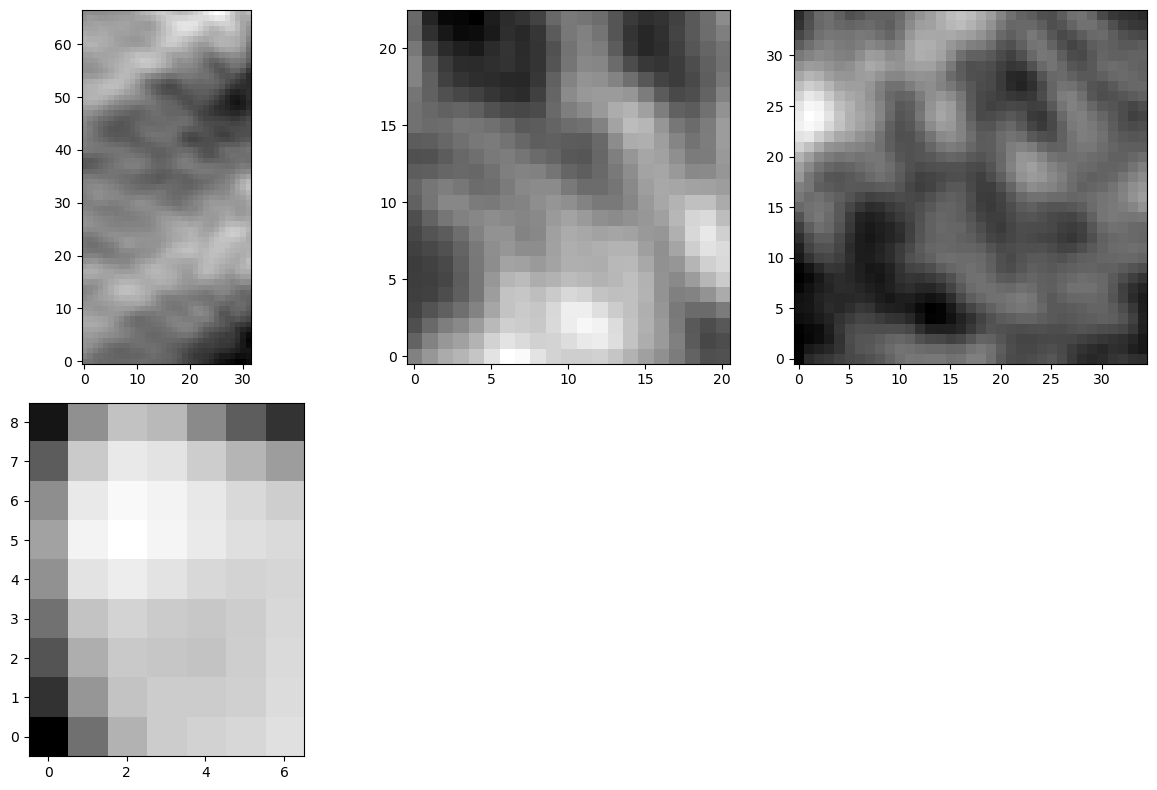

In [313]:
masked_imgss = []
roiss = []
for j in range(len(imgs)):
    target_img = imgs[j]
    img_height, img_width = target_img.shape
    masked_imgs = []
    rois = []
    for i in range(len(rectangles)):
        mask = np.zeros_like(target_img, dtype=bool)
        bot_left_x, bot_left_y, width, height = rectangles[i]
        roi_slice = slice(bot_left_y, bot_left_y + height), slice(bot_left_x, bot_left_x + width)
        mask[roi_slice] = True
        masked_img = np.where(mask, target_img, 0.0)
        masked_imgs.append(masked_img)
        rois.append(target_img[roi_slice])
    masked_imgss.append(masked_imgs)
    roiss.append(rois)
# show_images(masked_imgss[0], None, [])
for i in range(len(roiss)):
    show_images(roiss[i], None, [])
# show_images([target_img[:80, :120]], None, [])

metrics

SNR

In [314]:
snrs = []
cnrs = []
for i in range(len(imgs)):
    rois = roiss[i]
    snr = aggregate_snr_rms(rois)
    snrs.append(snr)
    target_rois = [
        rois[3],
        rois[2],
    ]
    background_rois = [
        rois[0],
        rois[1],
    ]
    cnr_aggregate = calc_cnr_aggregate(target_rois, background_rois)
    cnrs.append(cnr_aggregate)
    print(file_names[i], f'{snr:.2f}', f'{cnr_aggregate:.2f}')


axial 34.57 46.18
helical-1 13.65 20.69
helical-2 15.82 12.67
